In [1]:
from re import L
import sys
import sklearn
import numpy as np
import pysindy as ps
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.integrate import solve_ivp
import random
np.random.seed(seed=100)

import scienceplots
# plt.style.use(['science', 'ieee'])
# plt.rc('font', size=14)

In [2]:
data = np.loadtxt('hh-data.txt')
t_data  = data[0:, 0]
v_data  = data[0:, 1]
m_data  = data[0:, 2]
h_data  = data[0:, 3]
n_data  = data[0:, 4]

X = np.zeros((len(t_data), 4))
X[:, 0] = v_data
X[:, 1] = m_data
X[:, 2] = h_data
X[:, 3] = n_data

dt = t_data[1] - t_data[0]

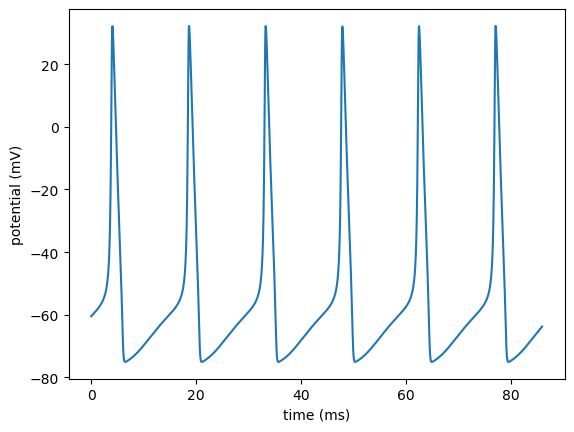

In [3]:
plt.plot(t_data, X[:, 0], label="V")
plt.xlabel("time (ms)")
plt.ylabel("potential (mV)")
plt.show()

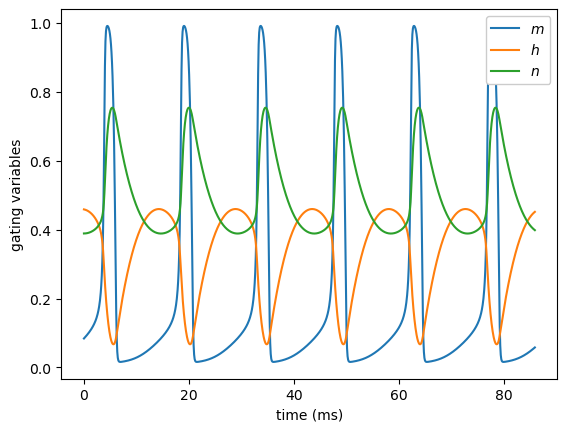

In [4]:
plt.plot(t_data, X[:, 1], label="$m$")
plt.plot(t_data, X[:, 2], label="$h$")
plt.plot(t_data, X[:, 3], label="$n$")
plt.xlabel("time (ms)")
plt.ylabel('gating variables')
plt.legend(loc='upper right', frameon=True, framealpha=1.0)
plt.show()

In [5]:

pca = PCA().fit(X)
print(pca.explained_variance_ratio_)

[9.99920915e-01 7.05876513e-05 8.41699034e-06 7.99178073e-08]


In [6]:
# STEP 1

# Stack data
X = np.column_stack((v_data, m_data, h_data, n_data))

dt = t_data[1] - t_data[0]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
# STEP 2

pca = PCA(n_components=2)
Z = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance (2D):", np.sum(pca.explained_variance_ratio_))

Explained variance ratio: [0.71111789 0.27665726]
Total explained variance (2D): 0.9877751433757316


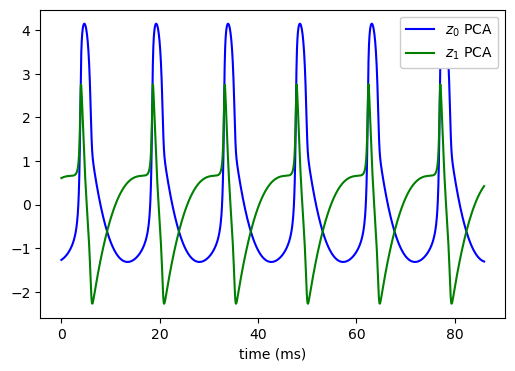

In [8]:
plt.figure(figsize=(6,4))
plt.plot(t_data, Z[:,0], 'b', label="$z_0$ PCA")
plt.plot(t_data, Z[:,1], 'g', label="$z_1$ PCA")
plt.xlabel("time (ms)")
# plt.ylabel("z2")
plt.legend(loc='upper right', frameon=True, framealpha=1.0)
# plt.title("Latent Space Phase Portrait")
# plt.tight_layout()
plt.savefig('z_pca.pdf', dpi=300)
plt.show()

In [9]:
# STEP 3 ---------- 

# TO-DO: melhorar aqui a busca pelo modelo, variando o lambda, optimizer, etc...

library = ps.PolynomialLibrary(degree=3)

opt = ps.STLSQ(
    threshold=0.5,
    # thresholder="l1",
    max_iter=1000,
    normalize_columns=True
)

# SR3
# opt = ps.SR3(
#     threshold=0.5,
#     max_iter=1000,
#     nu=1.0,
#     normalize_columns=True
# )

# SSR (Stepwise Sparse Regression)
# opt = ps.SSR(
#     max_iter=1000,
#     normalize_columns=True
# )

# Elastic Net
# opt = ps.ElasticNet(
#     alpha=0.01,
#     l1_ratio=0.5,
#     max_iter=10000
# )

model = ps.SINDy(
    differentiation_method=ps.SINDyDerivative(),
    feature_library=library,
    optimizer=opt,
    feature_names=["z1", "z2"]
)

model.fit(Z, t=dt)
model.print()

(z1)' = -0.541 1 + 0.298 z1 + 1.849 z2 + 0.407 z1^2 + 1.675 z1 z2 + 1.284 z2^2 + -0.127 z1^3 + -0.390 z1^2 z2 + -0.422 z1 z2^2 + -0.141 z2^3
(z2)' = -0.673 1 + -0.163 z1 + 0.839 z2 + 0.508 z1^2 + 1.663 z1 z2 + 1.230 z2^2 + -0.137 z1^3 + -0.409 z1^2 z2 + -0.423 z1 z2^2 + -0.144 z2^3


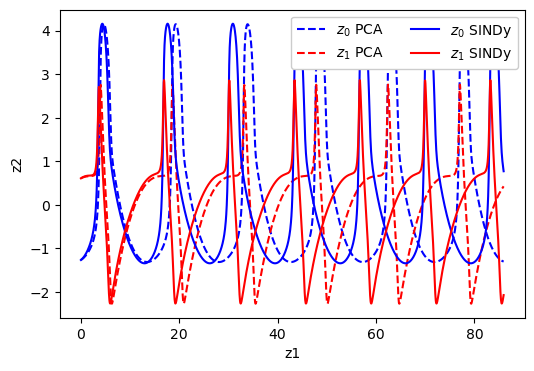

In [10]:
Z_sim = model.simulate(Z[0], t_data) 

plt.figure(figsize=(6,4))
plt.plot(t_data, Z[:,0], 'b--', label="$z_0$ PCA")
plt.plot(t_data, Z[:,1], 'r--', label="$z_1$ PCA")
plt.plot(t_data, Z_sim[:,0], 'b',  label="$z_0$ SINDy")
plt.plot(t_data, Z_sim[:,1], 'r', label="$z_1$ SINDy")
plt.xlabel("z1")
plt.ylabel("z2")
plt.legend(loc='upper right', frameon=True, framealpha=1.0, ncol=2)

plt.show()

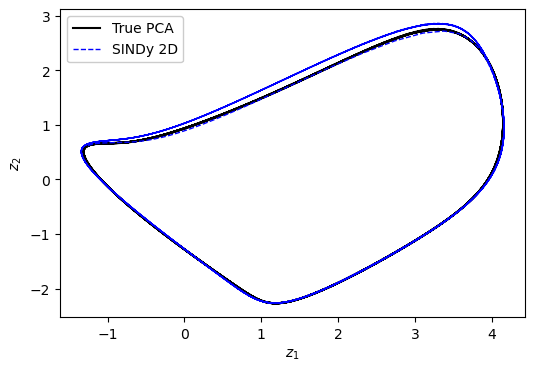

In [ ]:
Z_sim = model.simulate(Z[0]+0.01, t_data)

plt.figure(figsize=(6,4))
plt.plot(Z[:,0], Z[:,1], 'k', label="True PCA")
plt.plot(Z_sim[:,0], Z_sim[:,1], 'b--', linewidth=1, label="SINDy 2D")
plt.xlabel("$z_1$")
plt.ylabel("$z_2$")
plt.legend(loc='upper left', frameon=True, framealpha=1.0)
plt.show()

In [12]:
Z[0]

array([-1.26607113,  0.60911538])

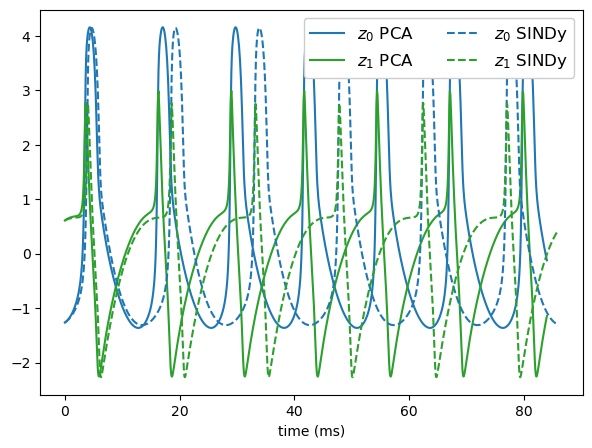

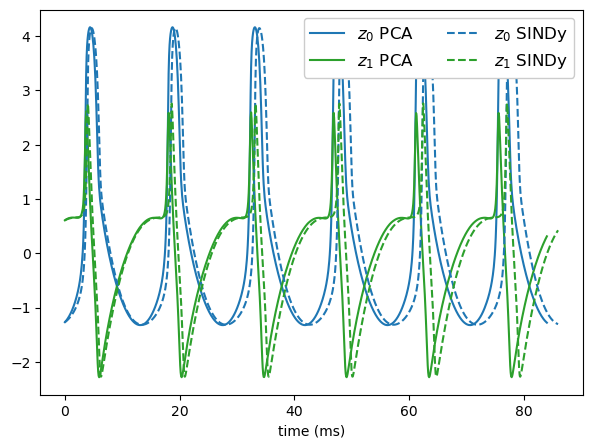

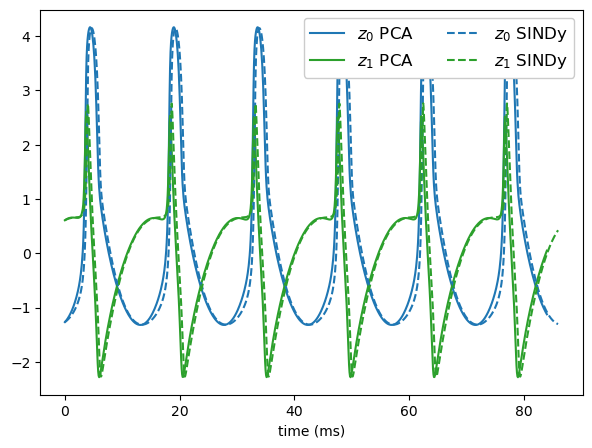

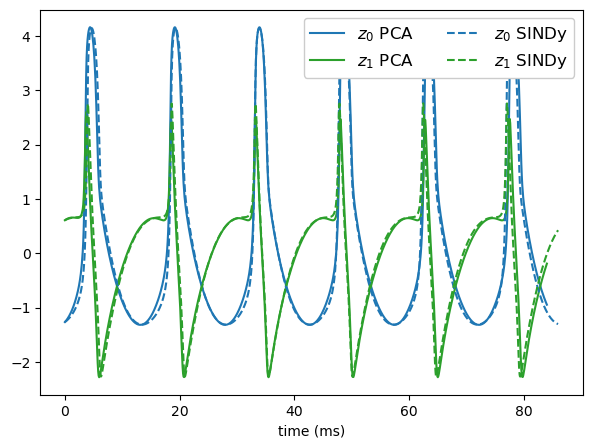

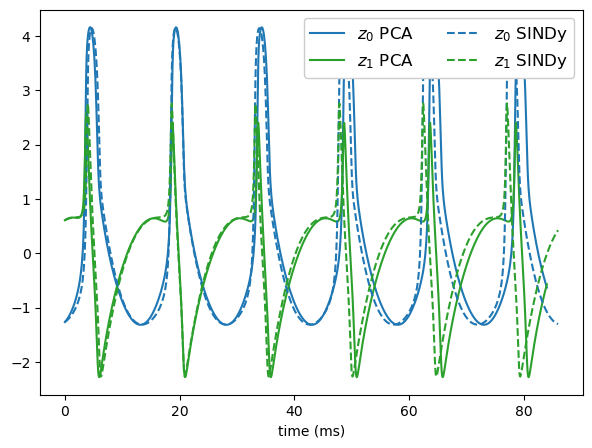

In [ ]:
t0 = 0.0
tf = 84
n_points = 1000
t_eval = np.linspace(t0, tf, n_points)

z0 = [-1.26607113,  0.60911538]

perturbacoes = np.array([
    -0.02, +0.020, 0.022, +0.023, +0.024
])

for delta in perturbacoes:

    def modelo_perturbado(t, Z):
        z1, z2 = Z

        dz1 = (
            (-0.541 + delta)
            + 0.298*z1
            + 1.849*z2
            + 0.407*z1**2
            + 1.675*z1*z2
            + 1.284*z2**2
            - 0.127*z1**3
            - 0.390*z1**2*z2
            - 0.422*z1*z2**2
            - 0.141*z2**3
        )

        dz2 = (
            (-0.673)
            - 0.163*z1
            + 0.839*z2
            + 0.508*z1**2
            + 1.663*z1*z2
            + 1.230*z2**2
            - 0.137*z1**3
            - 0.409*z1**2*z2
            - 0.423*z1*z2**2
            - 0.144*z2**3
        )

        # dz1 = (
        #     0.864*z1
        #     + 1.799*z2
        #     + 0.419*z1**2
        #     + 1.541*z1*z2
        #     + 0.960*z2**2
        #     - 0.178*z1**3
        #     - 0.303*z1**2*z2
        #     - 0.409*z1*z2**2
        #     - 0.146*z2**3
        # )

        # dz2 = (
        #     -0.573 + delta
        #     + 0.815*z2
        #     + 0.541*z1**2
        #     + 1.633*z1*z2
        #     + 1.163*z2**2
        #     - 0.158*z1**3
        #     - 0.383*z1**2*z2
        #     - 0.432*z1*z2**2
        #     - 0.144*z2**3
        # )

        return [dz1, dz2]

    sol = solve_ivp(
        modelo_perturbado,
        (t0, tf),
        z0,
        t_eval=t_eval,
        method='RK45'
    )

    t = sol.t
    z1 = sol.y[0]
    z2 = sol.y[1]

    plt.figure(figsize=(7,5))

    plt.plot(t, z1, color='tab:blue', linestyle='-', label='$z_0$ PCA')
    plt.plot(t, z2, color='tab:green', linestyle='-', label='$z_1$ PCA')

    plt.plot(t_data, Z[:,0], color='tab:blue', linestyle='--', label='$z_0$ SINDy')
    plt.plot(t_data, Z[:,1], color='tab:green', linestyle='--', label='$z_1$ SINDy')

    # plt.title(f"delta = {delta:+.4f}")
    plt.xlabel('time (ms)')
    plt.legend(loc='upper right', frameon=True, framealpha=1.0, ncol=2, fontsize=12)

    # formatar delta para nome de arquivo
    delta_str = f"{delta:+.4f}".replace('.', '_').replace('+', 'p').replace('-', 'm')
    plt.savefig(f"simulacao_delta_{delta_str}.pdf", dpi=300, bbox_inches='tight')

    plt.show()